# 🎯 Computer Vision Seminar: Object Detection
## Реализация NMS и mAP с нуля + Практика на YOLOv8

**Уровень:** Intermediate | **Время:** ~2 часа | **Инструменты:** Python, NumPy, Matplotlib, Ultralytics

### 📋 План семинара:
1. [Теория: ключевые концепции](#теория)
2. [Часть 1: Non-Maximum Suppression (NMS)](#nms)
3. [Часть 2: Mean Average Precision (mAP)](#map)
4. [Часть 3: Практика на YOLOv8](#yolo)
5. [Домашнее задание](#homework)

<div class="alert alert-info">
💡 <b>Совет:</b> Запускайте ячейки последовательно. Код с решениями спрятан в скрытых ячейках — раскройте их, если застряли!
</div>

<a id="теория"></a>
## 📚 1. Теория: ключевые концепции

### 🔍 Object Detection: что оцениваем?

| Концепция | Формула/Описание | Зачем нужна |
|-----------|-----------------|-------------|
| **IoU** | `Intersection / Union` | Мера качества бокса |
| **NMS** | Подавление дубликатов по IoU-порогу | Убрать множественные детекции одного объекта |
| **Precision** | `TP / (TP + FP)` | Точность: какая доля детекций верна |
| **Recall** | `TP / (TP + FN)` | Полнота: какую долю объектов нашли |
| **AP** | Площадь под PR-кривой | Качество для одного класса |
| **mAP** | Среднее AP по классам/порогам | Итоговая метрика детектора |

### 🎯 Важное правило матчинга:
> **Один Ground Truth = максимум один True Positive**
> 
> Если модель предсказала 5 боксов на одного человека → только один станет TP (с лучшим IoU), остальные 4 → FP.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
# Настройка визуализации
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

<a id="nms"></a>
## 🔧 Часть 1: Non-Maximum Suppression (NMS)

### 📝 Задание 1.1: Реализация IoU
Напишите функцию, которая считает Intersection over Union для двух боксов в формате `[x1, y1, x2, y2]`.

In [2]:
def calculate_iou(box1, box2):
    """
    Вычисляет Intersection over Union для двух боксов.

    Args:
        box1, box2: np.array shape (4,) [x1, y1, x2, y2]

    Returns:
        float: IoU в диапазоне [0, 1]
    """
    box1 = np.array(box1, dtype=np.float32)
    box2 = np.array(box2, dtype=np.float32)

    # Координаты пересечения
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Площадь пересечения (0 если нет перекрытия)
    intersection = max(0.0, x2 - x1) * max(0.0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return float(intersection / union)


# 🔍 Тест функции (не меняйте!)
def test_iou():
    # Тест 1: Полное совпадение
    assert np.isclose(calculate_iou([0,0,10,10], [0,0,10,10]), 1.0), 'Тест 1 failed'

    # Тест 2: Нет пересечения
    assert np.isclose(calculate_iou([0,0,10,10], [20,20,30,30]), 0.0), 'Тест 2 failed'

    # Тест 3: Частичное пересечение (классический пример)
    box_a = np.array([0, 0, 10, 10])
    box_b = np.array([5, 5, 15, 15])
    expected = 25 / (100 + 100 - 25)  # 25 / 175 = 0.142857...
    assert np.isclose(calculate_iou(box_a, box_b), expected, atol=1e-4), 'Тест 3 failed'

    print('✅ Все тесты IoU пройдены!')

test_iou()

✅ Все тесты IoU пройдены!


### 📝 Задание 1.2: Реализация NMS
Напишите функцию Non-Maximum Suppression, которая:
1. Сортирует боксы по уверенности (убывание)
2. Берет бокс с максимальной уверенностью → добавляет в результат
3. Удаляет все боксы, у которых IoU с выбранным > порога
4. Повторяет, пока боксы не кончатся

In [3]:
def nms(boxes, scores, iou_threshold=0.5):
    """
    Non-Maximum Suppression.

    Args:
        boxes: np.array shape (N, 4) [x1, y1, x2, y2]
        scores: np.array shape (N,) confidence scores
        iou_threshold: порог для подавления дубликатов

    Returns:
        list: индексы боксов, которые нужно оставить
    """
    if len(boxes) == 0:
        return []

    # Сортируем по убыванию confidence
    order = np.argsort(scores)[::-1]
    keep  = []

    while len(order) > 0:
        i = order[0]          # бокс с максимальной уверенностью
        keep.append(i)

        if len(order) == 1:
            break

        # IoU выбранного бокса с остальными
        remaining = order[1:]
        ious = np.array([calculate_iou(boxes[i], boxes[j]) for j in remaining])

        # Оставляем только те, у которых IoU < threshold
        order = remaining[ious < iou_threshold]

    return keep


# 🔍 Тест NMS
def test_nms():
    test_boxes = np.array([
        [100, 100, 200, 200],
        [110, 110, 210, 210],
        [105, 105, 205, 205],
        [500, 500, 600, 600],
        [510, 510, 610, 610],
    ])
    test_scores = np.array([0.9, 0.8, 0.7, 0.95, 0.6])

    keep = nms(test_boxes, test_scores, iou_threshold=0.5)

    assert len(keep) == 2, f'Ожидали 2 бокса, получили {len(keep)}'
    kept_scores = test_scores[keep]
    assert set(kept_scores) == {0.95, 0.9}, f'Неверные скоры: {kept_scores}'

    print('✅ Все тесты NMS пройдены!')
    return test_boxes, test_scores, keep

boxes, scores, keep = test_nms()

✅ Все тесты NMS пройдены!


### 📊 Визуализация работы NMS

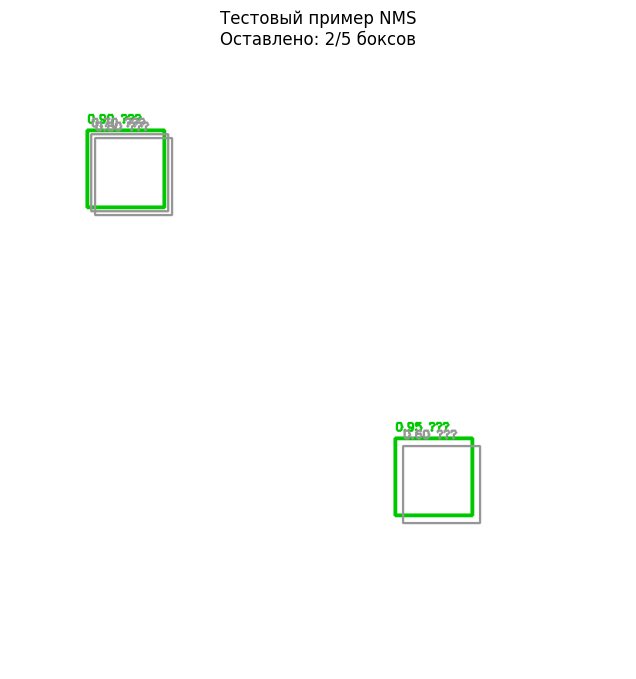

In [4]:
def visualize_nms(boxes, scores, keep_indices, img_size=(800, 800), title="NMS Result"):
    """Визуализирует боксы до и после NMS"""
    img = np.ones((img_size[0], img_size[1], 3), dtype=np.uint8) * 255
    
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.astype(int)
        if i in keep_indices:
            color = (0, 200, 0)  # Зеленый = оставлен
            thickness = 4
            label = f"{scores[i]:.2f} ✓"
        else:
            color = (150, 150, 150)  # Серый = подавлен
            thickness = 2
            label = f"{scores[i]:.2f} ✗"
        
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(img, label, (x1, y1-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"{title}\nОставлено: {len(keep_indices)}/{len(boxes)} боксов")
    plt.axis("off")
    plt.show()

# Визуализируем результат теста
visualize_nms(boxes, scores, keep, title="Тестовый пример NMS")

<a id="map"></a>
## 📈 Часть 2: Mean Average Precision (mAP)

### 📝 Задание 2.1: Матчинг предсказаний с Ground Truth

In [5]:
def match_predictions(gt_boxes, pred_boxes, pred_scores, iou_threshold=0.5):
    """
    Сопоставляет предсказания с ground truth для расчета метрик.

    Args:
        gt_boxes:    np.array (M, 4)
        pred_boxes:  np.array (N, 4)
        pred_scores: np.array (N,)
        iou_threshold: порог для TP/FP решения

    Returns:
        tp_fp:         np.array (N,) — 1 TP, 0 FP (по убыванию confidence)
        sorted_scores: np.array (N,)
    """
    n_gt   = len(gt_boxes)
    n_pred = len(pred_boxes)

    if n_pred == 0:
        return np.array([]), np.array([])

    # Сортируем предсказания по убыванию confidence
    sort_idx      = np.argsort(pred_scores)[::-1]
    sorted_boxes  = pred_boxes[sort_idx]
    sorted_scores = pred_scores[sort_idx]

    tp_fp      = np.zeros(n_pred)
    gt_matched = np.zeros(n_gt, dtype=bool)  # какие GT уже 'пойманы'

    for i, box in enumerate(sorted_boxes):
        if n_gt == 0:
            break

        # IoU с каждым GT
        ious = np.array([calculate_iou(box, gt) for gt in gt_boxes])

        # Занятые GT не участвуют в матчинге
        ious[gt_matched] = -1.0

        best_idx = int(np.argmax(ious))
        best_iou = ious[best_idx]

        if best_iou >= iou_threshold:
            tp_fp[i]             = 1
            gt_matched[best_idx] = True
        # иначе tp_fp[i] остается 0 — FP

    return tp_fp, sorted_scores


# 🔍 Тест матчинга
def test_matching():
    np.random.seed(42)

    gt = np.array([
        [100, 100, 200, 200],
        [300, 300, 400, 400],
        [500, 100, 600, 200],
    ])

    pred = np.array([
        [105, 105, 205, 205, 0.9],
        [110, 110, 210, 210, 0.8],
        [305, 305, 405, 405, 0.95],
        [50,  50,  80,  80,  0.99],
        [500, 100, 600, 200, 0.7],
    ])

    tp_fp, scores = match_predictions(gt, pred[:, :4], pred[:, 4], iou_threshold=0.5)

    expected_tp_fp = np.array([0, 1, 1, 0, 1])
    assert np.array_equal(tp_fp, expected_tp_fp), f'Expected {expected_tp_fp}, got {tp_fp}'
    assert np.all(scores == np.sort(pred[:, 4])[::-1]), 'Scores не отсортированы!'

    print('✅ Тест матчинга пройден!')
    return gt, pred, tp_fp, scores

gt, pred, tp_fp, scores = test_matching()

✅ Тест матчинга пройден!


### 📝 Задание 2.2: Precision-Recall Curve и AP

Precision: [0.     0.5    0.6667 0.5    0.6   ]
Recall:    [0.     0.3333 0.6667 0.6667 1.    ]
AP@0.5:    0.6444


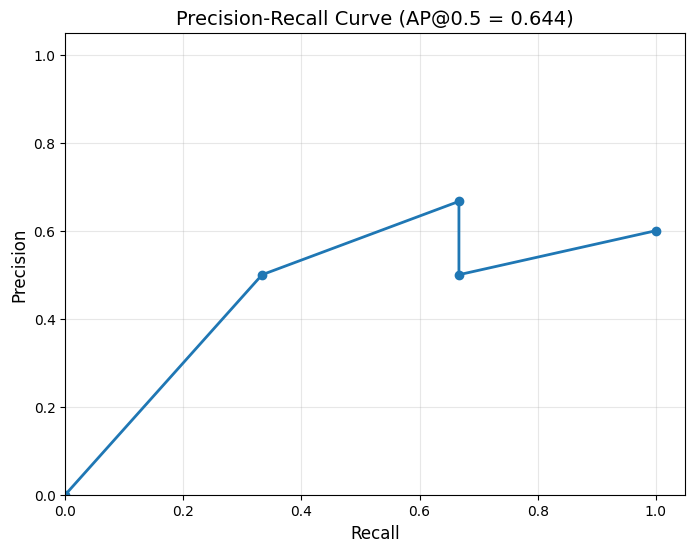

In [6]:
def calculate_precision_recall(tp_fp, n_gt_total):
    """
    Считает кривую Precision-Recall по отсортированным предсказаниям.
    """
    n_pred = len(tp_fp)
    if n_pred == 0:
        return np.array([]), np.array([])

    cum_tp = np.cumsum(tp_fp)
    cum_fp = np.cumsum(1 - tp_fp)

    precision = cum_tp / (cum_tp + cum_fp + 1e-6)
    recall    = cum_tp / (n_gt_total + 1e-6)

    return precision, recall


def calculate_ap_coco(precision, recall):
    """
    COCO-style AP: Area Under Curve с monotonicity check.
    """
    if len(precision) == 0:
        return 0.0

    mrec = np.concatenate(([0.], recall, [1.]))
    mpre = np.concatenate(([0.], precision, [0.]))

    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])

    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])
    return ap


# 🔍 Тест PR-кривой и AP
def test_pr_curve():
    tp_fp = np.array([0, 1, 1, 0, 1])
    n_gt  = 3

    prec, rec = calculate_precision_recall(tp_fp, n_gt)
    ap = calculate_ap_coco(prec, rec)

    print(f'Precision: {np.round(prec, 4)}')
    print(f'Recall:    {np.round(rec,  4)}')
    print(f'AP@0.5:    {ap:.4f}')

    plt.figure(figsize=(8, 6))
    plt.plot(rec, prec, marker='o', linewidth=2, markersize=6)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curve (AP@0.5 = {ap:.3f})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1.05])
    plt.ylim([0, 1.05])
    plt.show()

    return ap

ap_val = test_pr_curve()

### 📝 Задание 2.3: mAP@0.5:0.95 (COCO Standard)

📊 Результаты:
mAP@0.5:0.95 = 0.4842

AP по порогам:
  IoU=0.50 → AP=0.6417
  IoU=0.55 → AP=0.6417
  IoU=0.60 → AP=0.6417
  IoU=0.65 → AP=0.6417
  IoU=0.70 → AP=0.6417
  IoU=0.75 → AP=0.6417
  IoU=0.80 → AP=0.6417
  IoU=0.85 → AP=0.1167
  IoU=0.90 → AP=0.1167
  IoU=0.95 → AP=0.1167


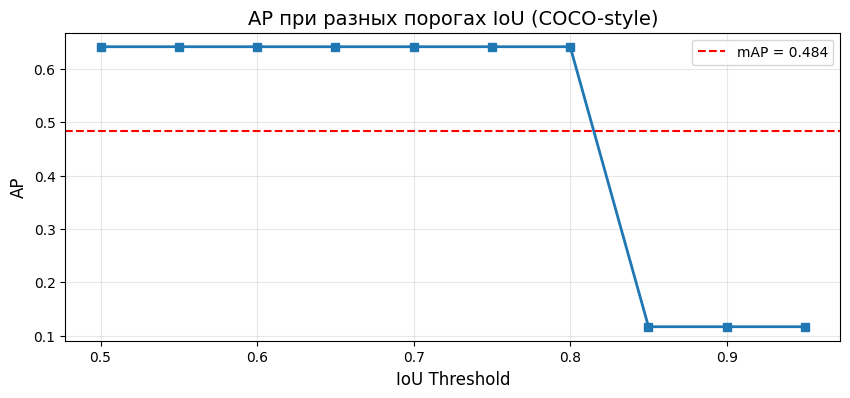

In [7]:
def calculate_map_coco(gt_boxes, pred_boxes, pred_scores, iou_thresholds=None):
    """
    Считает mAP в стиле COCO: среднее AP по порогам IoU от 0.5 до 0.95 с шагом 0.05.
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 0.96, 0.05)
    
    aps = []
    
    for thresh in iou_thresholds:
        tp_fp, scores = match_predictions(gt_boxes, pred_boxes, pred_scores, iou_threshold=thresh)
        if len(tp_fp) == 0:
            aps.append(0.0)
            continue
        prec, rec = calculate_precision_recall(tp_fp, len(gt_boxes))
        ap = calculate_ap_coco(prec, rec)
        aps.append(ap)
    
    return np.mean(aps), np.array(aps), iou_thresholds


# 🔍 Полный тест на синтетических данных
def full_test_map():
    np.random.seed(123)
    
    # Ground Truth: 5 объектов
    gt = np.array([
        [100, 100, 200, 200],
        [300, 300, 400, 400],
        [500, 100, 600, 200],
        [100, 500, 200, 600],
        [800, 800, 900, 900]
    ])
    
    # Predictions: смесь хороших, плохих и дубликатов
    pred = np.array([
        [105, 105, 205, 205, 0.95],   # Хороший на GT 0
        [110, 110, 210, 210, 0.80],   # Дубликат GT 0 → FP
        [305, 305, 405, 405, 0.85],   # Хороший на GT 1
        [500, 100, 600, 200, 0.90],   # Идеальный на GT 2
        [100, 500, 200, 600, 0.40],   # Хороший на GT 3, но низкий скор
        [900, 900, 950, 950, 0.88],   # Плохой на GT 4 (малый IoU)
        [50, 50, 80, 80, 0.99],       # FP (вообще не там)
        [805, 805, 895, 895, 0.70]    # Хороший на GT 4
    ])
    
    mAP, aps, thresholds = calculate_map_coco(gt, pred[:, :4], pred[:, 4])
    
    print(f"📊 Результаты:")
    print(f"mAP@0.5:0.95 = {mAP:.4f}")
    print(f"\nAP по порогам:")
    for t, ap in zip(thresholds, aps):
        print(f"  IoU={t:.2f} → AP={ap:.4f}")
    
    # График зависимости AP от IoU порога
    plt.figure(figsize=(10, 4))
    plt.plot(thresholds, aps, marker='s', linewidth=2)
    plt.axhline(y=mAP, color='r', linestyle='--', label=f'mAP = {mAP:.3f}')
    plt.xlabel('IoU Threshold', fontsize=12)
    plt.ylabel('AP', fontsize=12)
    plt.title('AP при разных порогах IoU (COCO-style)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return mAP

# Запустите полный тест:
mAP_result = full_test_map()

<a id="yolo"></a>
## 🚀 Часть 3: Практика на YOLOv8

In [9]:
# 📦 Установка ultralytics (если еще не установлено)
!pip install -q ultralytics opencv-python requests pillow

from ultralytics import YOLO
import requests
from PIL import Image
import io


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.5 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### 🔍 Инференс предобученной модели

In [10]:
# Загружаем легкую модель YOLOv8n (nano)
model = YOLO("yolov8n.pt")
print(f"✅ Модель загружена: {model.task} детекция, {len(model.names)} классов")

✅ Модель загружена: detect детекция, 80 классов


🖼 Изображение: (1080, 810, 3)


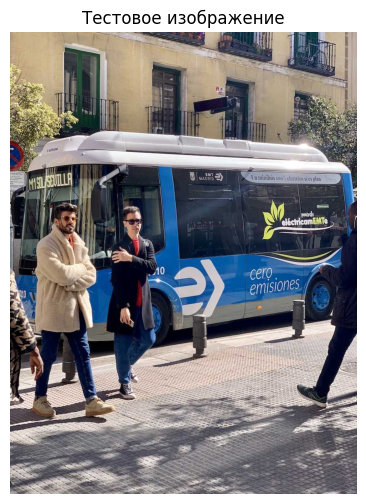

In [11]:
# Скачиваем и загружаем тестовое изображение
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(io.BytesIO(response.content)))

print(f"🖼 Изображение: {img.shape}")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Тестовое изображение")
plt.show()

In [12]:
# 🔮 Запускаем инференс с нашими параметрами (без встроенного NMS для демонстрации)
results = model(img, conf=0.25, iou=0.45, verbose=False)
res = results[0]

# Извлекаем данные для анализа (наши реализации)
boxes_yolo = res.boxes.xyxy.cpu().numpy()      # [x1, y1, x2, y2]
scores_yolo = res.boxes.conf.cpu().numpy()      # confidence
classes_yolo = res.boxes.cls.cpu().numpy().astype(int)  # class ids

print(f"📦 Найдено объектов: {len(boxes_yolo)}")
print(f"🏷 Классы: {[model.names[int(c)] for c in classes_yolo]}")
print(f"🎯 Confidence: {scores_yolo.round(3)}")

📦 Найдено объектов: 5
🏷 Классы: ['bus', 'person', 'person', 'person', 'person']
🎯 Confidence: [      0.868       0.864       0.833       0.811       0.334]


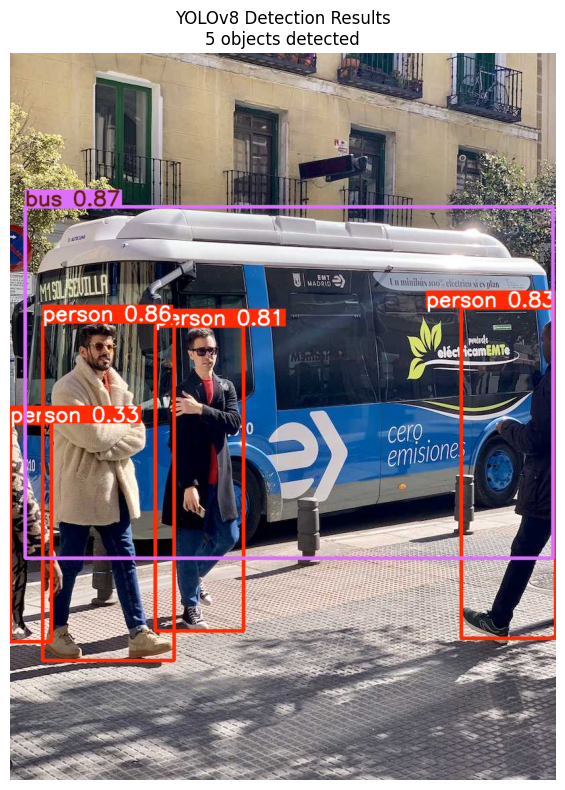

In [13]:
# 🎨 Визуализация результатов YOLO (встроенная)
plt.figure(figsize=(12, 8))
plt.imshow(res.plot())
plt.axis("off")
plt.title(f"YOLOv8 Detection Results\n{len(boxes_yolo)} objects detected")
plt.tight_layout()
plt.show()

### 🔬 Сравнение: Наш NMS vs YOLO NMS

In [14]:
# Применяем НАШ NMS к сырым предсказаниям YOLO
# (в реальности YOLO уже применил NMS, но для демо предположим, что у нас сырые боксы)

# Для демонстрации: добавим искусственные дубликаты к некоторым боксам
boxes_with_dups = np.vstack([
    boxes_yolo,
    boxes_yolo[:3] + np.random.randn(3, 4) * 5,  # Небольшие сдвиги = дубликаты
])
scores_with_dups = np.hstack([
    scores_yolo,
    scores_yolo[:3] * 0.9  # Чуть меньшая уверенность для дубликатов
])

print(f"Боксов с дубликатами: {len(boxes_with_dups)}")

# Применяем наш NMS
keep_ours = nms(boxes_with_dups, scores_with_dups, iou_threshold=0.45)

print(f"✅ После нашего NMS: {len(keep_ours)} боксов осталось")
print(f"📉 Удалено дубликатов: {len(boxes_with_dups) - len(keep_ours)}")

Боксов с дубликатами: 8
✅ После нашего NMS: 5 боксов осталось
📉 Удалено дубликатов: 3


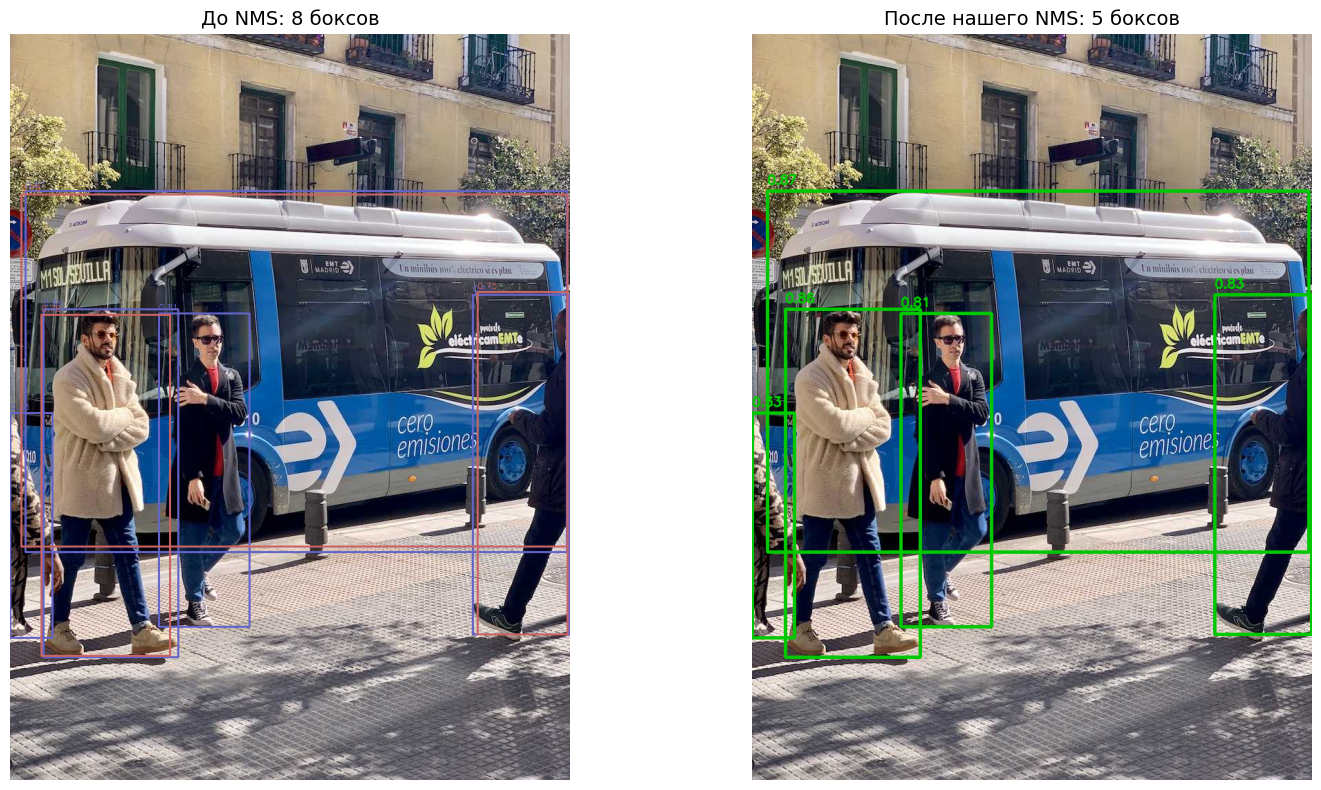

In [15]:
# 🖼 Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Левая: все боксы с дубликатами (до NMS)
img_before = img.copy()
for i, (box, score) in enumerate(zip(boxes_with_dups, scores_with_dups)):
    x1, y1, x2, y2 = box.astype(int)
    color = (200, 100, 100) if i >= len(boxes_yolo) else (100, 100, 200)  # дубликаты / оригиналы
    cv2.rectangle(img_before, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img_before, f"{score:.2f}", (x1, y1-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

axes[0].imshow(img_before)
axes[0].set_title(f"До NMS: {len(boxes_with_dups)} боксов", fontsize=14)
axes[0].axis("off")

# Правая: после нашего NMS
img_after = img.copy()
for i in keep_ours:
    x1, y1, x2, y2 = boxes_with_dups[i].astype(int)
    cv2.rectangle(img_after, (x1, y1), (x2, y2), (0, 200, 0), 3)
    cv2.putText(img_after, f"{scores_with_dups[i]:.2f}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

axes[1].imshow(img_after)
axes[1].set_title(f"После нашего NMS: {len(keep_ours)} боксов", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 📊 Быстрая валидация на датасете COCO128

In [ ]:
# 🔽 Скачиваем маленький датасет для быстрой проверки (опционально)
# !wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip
# !unzip -q coco128.zip

# # 🧪 Валидация модели (может занять 2-5 минут)
# print("🔄 Запускаем валидацию на COCO128...")
# metrics = model.val(data="coco128/coco128.yaml", verbose=False, save_json=False)
# 
# print(f"\n📈 Метрики модели:")
# print(f"mAP@0.5:    {metrics.box.map50:.3f}")
# print(f"mAP@0.5:0.95: {metrics.box.map:.3f}")
# print(f"Precision:  {metrics.box.mp:.3f}")
# print(f"Recall:     {metrics.box.mr:.3f}")

<a id="homework"></a>
## 📋 Домашнее Задание

**NMS с векторизацией** - Переписать `nms()` без Python-циклов

**mAP для нескольких классов** - Расширить `match_predictions()` для работы с мультиклассовыми данными (как в COCO)

**Анализ чувствительности** - Построить график mAP@0.5 в зависимости от `conf_threshold ∈ [0.1, 0.9]` 

**Soft-NMS:** Реализовать Soft-NMS (уменьшение confidence вместо удаления боксов)"

In [16]:
# HW 1: NMS с векторизованным расчётом IoU
def nms_vectorized(boxes, scores, iou_threshold=0.5):
    """
    NMS, где IoU считается для всех пар сразу (N×N матрица).
    Дорогой цикл по IoU заменён векторными операциями над массивами.
    """
    if len(boxes) == 0:
        return []

    boxes  = np.array(boxes, dtype=np.float32)
    scores = np.array(scores)
    order  = np.argsort(scores)[::-1]
    b      = boxes[order]

    x1, y1, x2, y2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]
    areas = (x2 - x1) * (y2 - y1)

    # Вся матрица IoU за один проход
    inter_x1 = np.maximum(x1[:, None], x1[None, :])
    inter_y1 = np.maximum(y1[:, None], y1[None, :])
    inter_x2 = np.minimum(x2[:, None], x2[None, :])
    inter_y2 = np.minimum(y2[:, None], y2[None, :])
    inter    = np.maximum(0, inter_x2 - inter_x1) * np.maximum(0, inter_y2 - inter_y1)
    union    = areas[:, None] + areas[None, :] - inter
    iou_mat  = inter / (union + 1e-6)

    suppressed = np.zeros(len(b), dtype=bool)
    keep = []
    for i in range(len(b)):
        if suppressed[i]:
            continue
        keep.append(int(order[i]))
        suppressed |= iou_mat[i] >= iou_threshold
        suppressed[i] = True

    return keep


# Проверяем, что результат совпадает с оригинальным NMS
tb = np.array([[100,100,200,200],[110,110,210,210],[105,105,205,205],
               [500,500,600,600],[510,510,610,610]], dtype=np.float32)
ts = np.array([0.9, 0.8, 0.7, 0.95, 0.6])

assert set(nms(tb, ts, 0.5)) == set(nms_vectorized(tb, ts, 0.5))
print(f'✅ nms_vectorized: оставлено {len(nms_vectorized(tb, ts, 0.5))} бокса')

✅ nms_vectorized: оставлено 2 бокса


In [17]:
# HW 2: mAP для нескольких классов
def calculate_map_multiclass(gt_boxes, gt_classes, pred_boxes, pred_scores, pred_classes,
                              iou_threshold=0.5):
    """
    mAP для мультиклассовой детекции.
    Матчинг происходит отдельно внутри каждого класса.
    """
    unique_cls = np.unique(np.concatenate([gt_classes, pred_classes]))
    class_aps  = {}

    for cls in unique_cls:
        gt_cls     = gt_boxes[gt_classes == cls]
        pred_mask  = pred_classes == cls
        pred_cls   = pred_boxes[pred_mask]
        scores_cls = pred_scores[pred_mask]

        if len(pred_cls) == 0:
            class_aps[int(cls)] = 0.0
            continue

        tp_fp, _ = match_predictions(gt_cls, pred_cls, scores_cls, iou_threshold)
        prec, rec = calculate_precision_recall(tp_fp, len(gt_cls))
        class_aps[int(cls)] = calculate_ap_coco(prec, rec)

    mAP = float(np.mean(list(class_aps.values()))) if class_aps else 0.0
    return mAP, class_aps


# Тест: 2 класса, по 2 объекта каждого
gt_b  = np.array([[100,100,200,200],[300,300,400,400],[500,100,600,200],[100,500,200,600]])
gt_cl = np.array([0, 0, 1, 1])
pr_b  = np.array([[105,105,205,205],[305,305,405,405],[502,102,602,202],[110,510,205,605]])
pr_s  = np.array([0.9, 0.85, 0.92, 0.6])
pr_cl = np.array([0, 0, 1, 1])

mAP_mc, class_aps = calculate_map_multiclass(gt_b, gt_cl, pr_b, pr_s, pr_cl)
print(f'✅ mAP@0.5 (multiclass) = {mAP_mc:.4f}')
for cls, ap in class_aps.items():
    print(f'   Class {cls}: AP = {ap:.4f}')

✅ mAP@0.5 (multiclass) = 1.0000
   Class 0: AP = 1.0000
   Class 1: AP = 1.0000


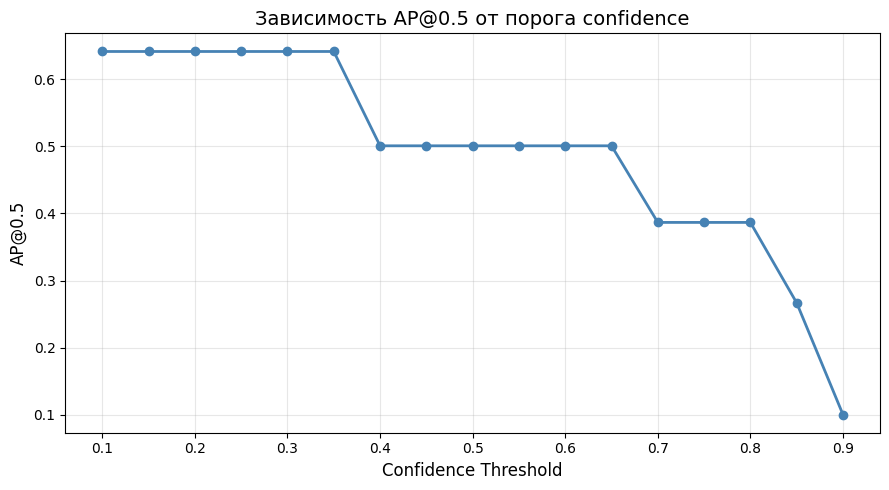

Лучший порог: conf=0.10  AP=0.6417


(array([        0.1,        0.15,         0.2,        0.25,         0.3,        0.35,         0.4,        0.45,         0.5,        0.55,         0.6,        0.65,         0.7,        0.75,         0.8,        0.85,         0.9]),
 [np.float64(0.6416664025695328),
  np.float64(0.6416664025695328),
  np.float64(0.6416664025695328),
  np.float64(0.6416664025695328),
  np.float64(0.6416664025695328),
  np.float64(0.6416664025695328),
  np.float64(0.5009521515465678),
  np.float64(0.5009521515465678),
  np.float64(0.5009521515465678),
  np.float64(0.5009521515465678),
  np.float64(0.5009521515465678),
  np.float64(0.5009521515465678),
  np.float64(0.3866664764445169),
  np.float64(0.3866664764445169),
  np.float64(0.3866664764445169),
  np.float64(0.2666665244445025),
  np.float64(0.099999930000039)])

In [18]:
# HW 3: Анализ чувствительности mAP@0.5 к порогу confidence
def analyze_conf_sensitivity(gt_boxes, pred_boxes_all, pred_scores_all, iou_threshold=0.5):
    conf_thresholds = np.arange(0.1, 0.95, 0.05)
    ap_values = []

    for thr in conf_thresholds:
        mask = pred_scores_all >= thr
        if mask.sum() == 0:
            ap_values.append(0.0)
            continue

        tp_fp, _ = match_predictions(gt_boxes, pred_boxes_all[mask],
                                      pred_scores_all[mask], iou_threshold)
        prec, rec = calculate_precision_recall(tp_fp, len(gt_boxes))
        ap_values.append(calculate_ap_coco(prec, rec))

    plt.figure(figsize=(9, 5))
    plt.plot(conf_thresholds, ap_values, marker='o', linewidth=2, color='steelblue')
    plt.xlabel('Confidence Threshold', fontsize=12)
    plt.ylabel('AP@0.5', fontsize=12)
    plt.title('Зависимость AP@0.5 от порога confidence', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    best_i = int(np.argmax(ap_values))
    print(f'Лучший порог: conf={conf_thresholds[best_i]:.2f}  AP={ap_values[best_i]:.4f}')
    return conf_thresholds, ap_values


# Данные из full_test_map
gt_s  = np.array([[100,100,200,200],[300,300,400,400],[500,100,600,200],
                   [100,500,200,600],[800,800,900,900]])
pr_s_ = np.array([[105,105,205,205],[110,110,210,210],[305,305,405,405],
                   [500,100,600,200],[100,500,200,600],[900,900,950,950],
                   [50,50,80,80],   [805,805,895,895]])
sc_s  = np.array([0.95, 0.80, 0.85, 0.90, 0.40, 0.88, 0.99, 0.70])

analyze_conf_sensitivity(gt_s, pr_s_, sc_s)

In [20]:
# HW 4: Soft-NMS
def soft_nms(boxes, scores, sigma=0.5, score_threshold=0.001):
    """
    Soft-NMS (Bodla et al., 2017).
    Вместо удаления дубликатов уменьшаем их confidence:
        score_new = score * exp(-IoU^2 / sigma)
    """
    boxes  = boxes.copy().astype(np.float32)
    scores = scores.copy().astype(np.float64)
    idx    = list(range(len(boxes)))
    keep   = []

    while idx:
        best = max(idx, key=lambda i: scores[i])
        keep.append(best)
        idx.remove(best)

        drop = []
        for j in idx:
            iou = calculate_iou(boxes[best], boxes[j])
            scores[j] *= np.exp(-(iou ** 2) / sigma)
            if scores[j] < score_threshold:
                drop.append(j)
        for j in drop:
            idx.remove(j)

    return keep, scores


# Сравниваем Hard NMS и Soft-NMS
tb2 = np.array([[100,100,200,200],[112,112,212,212],[108,108,205,205],
                 [500,500,600,600],[515,515,615,615]], dtype=np.float32)
ts2 = np.array([0.9, 0.85, 0.75, 0.95, 0.80])

keep_hard            = nms(tb2, ts2, iou_threshold=0.5)
keep_soft, sc_soft   = soft_nms(tb2, ts2, sigma=0.5)

print(f'Hard NMS : {len(keep_hard)} бокса — индексы {sorted(keep_hard)}')
print(f'Soft-NMS : {len(keep_soft)} бокса — индексы {sorted(keep_soft)}')
print(f'Итоговые scores (Soft-NMS): {np.round(sc_soft, 4)}')

Hard NMS : 2 бокса — индексы [np.int64(0), np.int64(3)]
Soft-NMS : 5 бокса — индексы [0, 1, 2, 3, 4]
Итоговые scores (Soft-NMS): [        0.9      0.3825      0.0623        0.95       0.422]


Soft-NMS мягче: сохраняет больше боксов с пониженным confidence,
что полезно при плотном расположении объектов (пешеходы, текст).

## 💡 Советы и ресурсы

### 🐛 Частые ошибки:
1. **IoU = 0 при касании:** Забыли `max(0, x2-x1)` → отрицательная площадь пересечения ❌
2. **Деление на ноль:** В Precision, когда `TP+FP = 0` → добавьте `+1e-6` в знаменатель
3. **Порядок сортировки:** Забыли сортировать по confidence перед матчингом → кривая PR будет неверной
4. **GT Matching:** Один GT помечают как matched для нескольких предсказаний → нарушается правило "один объект — одна детекция"

### 🔗 Полезные ссылки:
| Ресурс | Описание |
|--------|----------|
| 📄 [YOLOv8 Docs](https://docs.ultralytics.com) | Официальная документация Ultralytics |
| 📄 [COCO Evaluation](https://cocodataset.org/#detection-eval) | Как считается mAP в COCO |
| 🛠 [Roboflow](https://roboflow.com) | Бесплатная разметка и хостинг датасетов |
| 📊 [Papers With Code](https://paperswithcode.com/task/object-detection) | SOTA модели и бенчмарки |
| 🎓 [CS231n Detection](http://cs231n.stanford.edu/slides/2022/lecture_11_detection.pdf) | Лекция Stanford по детекции |